In [2]:
import os
from pathlib import Path

# Get the current directory of the notebook
notebook_path = Path.cwd()

ROOT = notebook_path.parent.parent

# Change the Working Directory for the whole process
os.chdir(ROOT)

print(f"Current Working Directory fixed to: {os.getcwd()}")

Current Working Directory fixed to: /srv/homes/onbo10/thesis_main


In [3]:
from src.Geometry.triangulation.triangulator import Triangulator, run_triangulation_pipeline
from src.Keypoints_detection.inference.inferencer import keypointsDetectionInferencer
from src.Keypoints_detection.inference.inferencer import keypointsDetectionInferencer
import glob
import random
import yaml
from src.Keypoints_detection.training.utils import get_device
from types import SimpleNamespace
from hrnet_config import cfg , update_config
from src.Keypoints_detection.training.utils import load_pretrained_HRNet
from ultralytics import YOLO
from src.Keypoints_detection.Top_down_keypoints_detection_pipline import KeypointDetectionPipeline
from mmpose.apis import init_model
import numpy as np
from utilities.visualizer import evaluate_MAE_and_compare

In [4]:
data_root_l='/srv/homes/onbo10/thesis_Ons/SurgePoseData/Extracted' 
data_root_r ='/srv/homes/onbo10/thesis_Ons/SurgePoseData/Extracted_right_test' 
split_file= '/srv/homes/onbo10/thesis_Ons/SurgePoseData/Extracted/video_split.yaml' 
org_dataset_path = '/srv/homes/onbo10/thesis_Ons/SurgePoseData'

In [5]:
device = get_device()

In [6]:
det_model = YOLO("results/Keypoints_detection/training_results/YOLO_trainings/YOLO_Object_Experiment1/weights/best.pt")
det_model.eval();

+ Yolov8 + ViTpose

In [7]:

config_file = 'configs/Vitpose/vitpose_surg_7kpt.py'
checkpoint_file = 'results/Keypoints_detection/training_results/ViTpose_trainings/Experiment1/best_coco_AP_epoch_160.pth'
model_type_vitpose='vitpose'
pose_model_vitpose = init_model(config_file, checkpoint_file, device=device)
pose_model_vitpose.eval();

Loads checkpoint by local backend from path: results/Keypoints_detection/training_results/ViTpose_trainings/Experiment1/best_coco_AP_epoch_160.pth


In [8]:

vitpose_pipeline = KeypointDetectionPipeline(det_model,pose_model_vitpose,model_type_vitpose, device= device)


In [9]:

inferencer =  keypointsDetectionInferencer(vitpose_pipeline,'pipeline',device)


In [10]:

tri = Triangulator(num_keypoints=7)

# Run the pipeline
all_results_vitpose = run_triangulation_pipeline(
    inferencer=inferencer,
    triangulator=tri,
    data_root_l= data_root_l,
    data_root_r=data_root_r,
    split_file=split_file,
    org_dataset_path= org_dataset_path
)



Total images in directory: 11356
Images to process (Test Split): 2004
Running batch inference on Test frames...
Processing Video: 000004
Processing Video: 000030
Processing Video: 000033
Processing Video: 000017
Processing Video: 000001
Processing Video: 000007


+ YOLO + HRNet (with aug)

In [23]:

# Load the pose model
cfg_file = 'configs/HRNet/w32_256x192_adam_lr1e-3__cropped_out7-finetune.yaml'
model_weights= 'results/Keypoints_detection/training_results/HRNet_trainings/Experiment3/training_checkpoints2026-03-02_23-16-42/model_epoch200.pth'

args = SimpleNamespace(
        cfg=cfg_file,
        opts=[],
        modelDir='',
        logDir='',
        dataDir='',
        prevModelDir=''
    )
update_config(cfg, args)
pose_model_hrnet= load_pretrained_HRNet(cfg, model_weights, finetuned=True)
device= get_device()
pose_model_hrnet.to(device)
pose_model_hrnet.eval()
model_type_hrnet='hrnet'


In [24]:
hrnet_pipeline = KeypointDetectionPipeline(det_model,pose_model_hrnet,model_type_hrnet, device= device)

In [25]:
hrnet_inferencer =  keypointsDetectionInferencer(hrnet_pipeline,'pipeline',device)


In [26]:

tri_hrnet = Triangulator(num_keypoints=7)

# Run the pipeline
all_results_hrnet = run_triangulation_pipeline(
    inferencer=hrnet_inferencer,
    triangulator=tri,
    data_root_l= data_root_l,
    data_root_r=data_root_r,
    split_file=split_file,
    org_dataset_path= org_dataset_path
)



Total images in directory: 11356
Images to process (Test Split): 2004
Running batch inference on Test frames...
Processing Video: 000004
Processing Video: 000030
Processing Video: 000033
Processing Video: 000017
Processing Video: 000001
Processing Video: 000007


In [15]:
np.nanmean(all_results_hrnet['reproj_err_l'])


6.439007944089164

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_error_comparison(results_dict, tool_names=['Tool 0', 'Tool 1'], model='Pipeline'):
    """
    Plots a comparison of reprojection errors.
    Expects results_dict to have 'reproj_err_l' and 'reproj_err_r'.
    """
    all_data = []
    
    # Flatten the errors for each tool/model
    for t_idx in range(len(results_dict['reproj_err_l'])):
        # Combine Left and Right errors for this tool
        l_errs = np.concatenate(results_dict['reproj_err_l'][t_idx])
        r_errs = np.concatenate(results_dict['reproj_err_r'][t_idx])
        combined = np.concatenate([l_errs, r_errs])
        
        # Remove NaNs
        valid_errs = combined[~np.isnan(combined)]
        
        for err in valid_errs:
            all_data.append({
                'Tool': tool_names[t_idx] if t_idx < len(tool_names) else f'Tool {t_idx}',
                'Error (pixels)': err
            })

    df = pd.DataFrame(all_data)

    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Tool', y='Error (pixels)', data=df, inner="quartile", palette="muted")
    plt.title('Distribution of Mean Reprojection Error (MRE)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Print Summary Table
    summary = df.groupby('Tool')['Error (pixels)'].agg(['mean', 'std', 'median']).round(3)
    print("--- Error Summary ---")
    print(summary)

/tmp/ipykernel_1720409/4158168580.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Tool', y='Error (pixels)', data=df, inner="quartile", palette="muted")


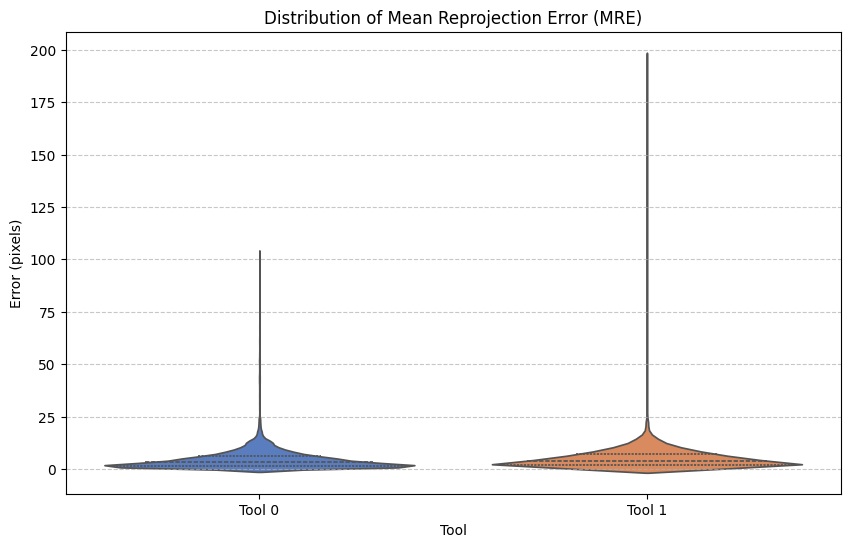

--- Error Summary ---
         mean    std  median
Tool                        
Tool 0  4.587  5.087   3.216
Tool 1  5.333  6.673   4.032


In [17]:
plot_error_comparison(all_results_vitpose)

/tmp/ipykernel_1720409/4158168580.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Tool', y='Error (pixels)', data=df, inner="quartile", palette="muted")


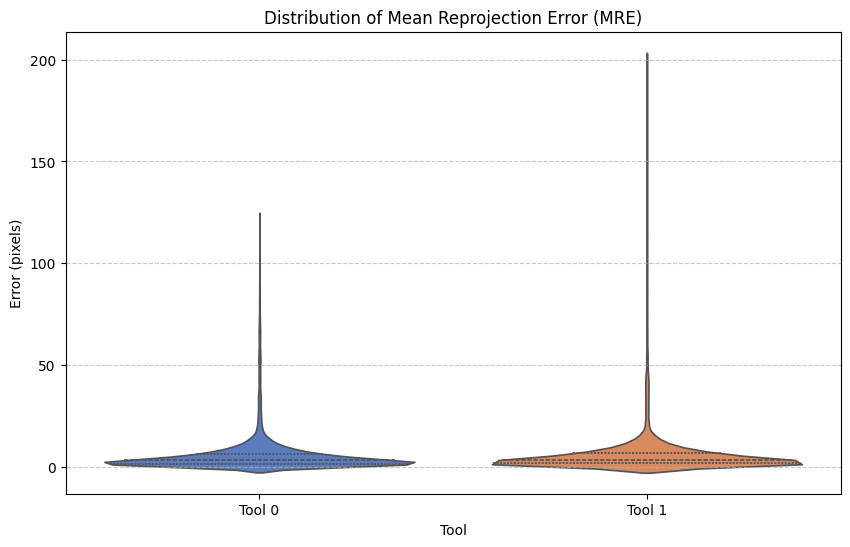

--- Error Summary ---
         mean     std  median
Tool                         
Tool 0  6.169   9.951   3.351
Tool 1  6.309  10.575   3.688


In [28]:
plot_error_comparison(all_results_hrnet)

/tmp/ipykernel_1720409/29039990.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=x_axis_col, y='Error (pixels)', data=df, inner="quartile", palette="Set2")


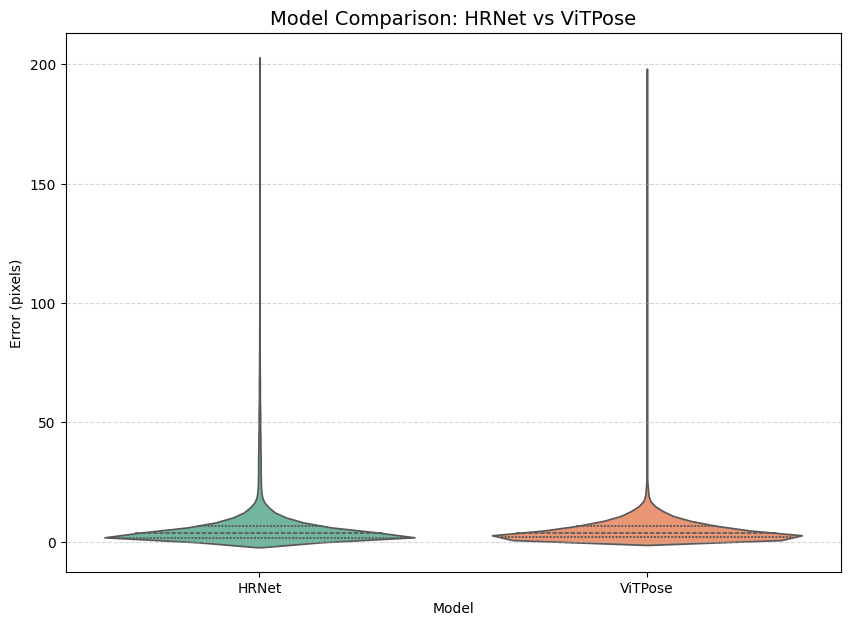

Results saved to results/Keypoints_detection/inference_results/triangulation


,mean,std,median,count
Model,,,,
HRNet,6.239,10.267,3.506,56000
ViTPose,4.959,5.943,3.619,56000


In [27]:
# This merges Tool 0 and Tool 1 for each model and plots them side-by-side
evaluate_MAE_and_compare([all_results_hrnet,all_results_vitpose], model_names=['HRNet', 'ViTPose'], output_dir='results/Keypoints_detection/inference_results/triangulation')

In [29]:
def calculate_success_metrics(results_dict):
    """
    Calculates the detection success rate for each tool in the results.
    """
    success_stats = {}
    
    for t_idx in range(len(results_dict['tri_3d'])):
        # List of 3D point arrays, one array per video
        all_videos_pts = results_dict['tri_3d'][t_idx]
        
        total_frames = 0
        valid_frames = 0
        
        for video_pts in all_videos_pts:
            # video_pts shape: (Frames, 7, 3)
            total_frames += len(video_pts)
            
            # A frame is "successful" if the 3D point is not NaN
            # We check the first keypoint's X coordinate as a proxy
            is_valid = ~np.isnan(video_pts[:, 0, 0])
            valid_frames += np.sum(is_valid)
            
        success_rate = (valid_frames / total_frames) * 100 if total_frames > 0 else 0
        success_stats[f'Tool {t_idx}'] = {
            'Total Frames': total_frames,
            'Successful Detections': valid_frames,
            'Success Rate (%)': round(success_rate, 2)
        }
        
    return success_stats

In [31]:
hrnet_stats = calculate_success_metrics(all_results_hrnet)
vitpose_stats = calculate_success_metrics(all_results_vitpose)

In [32]:
hrnet_stats

{'Tool 0': {'Total Frames': 2004,
  'Successful Detections': 2004,
  'Success Rate (%)': 100.0},
 'Tool 1': {'Total Frames': 2004,
  'Successful Detections': 1996,
  'Success Rate (%)': 99.6}}

In [33]:
vitpose_stats

{'Tool 0': {'Total Frames': 2004,
  'Successful Detections': 2004,
  'Success Rate (%)': 100.0},
 'Tool 1': {'Total Frames': 2004,
  'Successful Detections': 1996,
  'Success Rate (%)': 99.6}}

In [21]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def plot_inference_results(inferencer, img_path):
    """
    Plots the original image with detected keypoints and their indices.
    """
    # 1. Run inference
    # Your class returns (N, 7, 2) or (N, 7, 3)
    preds = inferencer.predict(img_path)
    
    # 2. Load and prepare image
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    ax = plt.gca()

    # Define a color palette for different tools (if more than one is detected)
    colors = ['cyan', 'lime', 'yellow', 'orange', 'magenta']

    if len(preds) == 0 or (isinstance(preds, np.ndarray) and preds.size == 0):
        plt.title(f"No tools detected in: {img_path.split('/')[-1]}")
    else:
        for t_idx, tool_kpts in enumerate(preds):
            color = colors[t_idx % len(colors)]
            
            # Extract x, y (and confidence if present)
            for k_idx in range(tool_kpts.shape[0]):
                x, y = tool_kpts[k_idx, 0], tool_kpts[k_idx, 1]
                
                # If the model provides confidence at index 2, check it
                # Otherwise, just check that coordinates aren't (0,0)
                conf = tool_kpts[k_idx, 2] if tool_kpts.shape[1] == 3 else 1.0
                
                if x > 0 and y > 0 and conf:
                    # Plot the point
                    ax.scatter(x, y, c=color, s=40, edgecolors='black')
                    
                    # Add the index label (0-6)
                    ax.text(x + 5, y - 5, str(k_idx), color=color, 
                            fontsize=12, fontweight='bold',
                            bbox=dict(facecolor='black', alpha=0.5, pad=1))

        plt.title(f"Inference Results: {len(preds)} tool(s) detected\n{img_path.split('/')[-1]}")

    plt.axis('off')
    plt.show()

# --- RUN IT ---
# img_test = "path/to/your/image.jpg"
# plot_inference_results(inferencer, img_test)

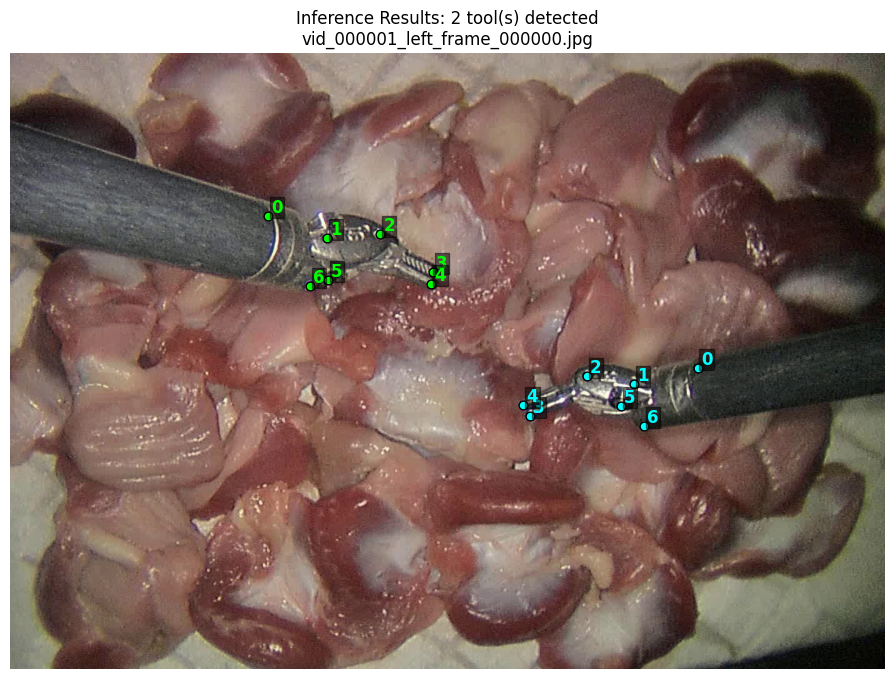

In [22]:
img_test = "/srv/homes/onbo10/thesis_main/data/SurgPose/SurgPose_for_HRNet/Extracted_left_right/extracted_frames/000001/vid_000001_left_frame_000000.jpg"
plot_inference_results(inferencer, img_test)